In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import sklearn
sklearn.set_config(display='text')
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN # 밀도 기반 클러스터링 알고리즘을 사용하기 위해 import 한다.

밀도 기반 클러스터링(Density-Based Spatial Cluctering of Applications with Noise, DBSCAN)

밀도 기반 클러스터링은 데이터 공간을 다루는 알고리즘으로 전체 공간에서 데이터가 가장 밀집된 영역을 찾는다. 그 밀집된 영역이 하나의 클러스터가 되며, 밀집 정도가 낮은 영역을 클러스터 외부 영역으로 구분한다. 이때, 밀집 정도를 파악하기 위해서 데이터 포인트간 거리를 측정하게 되는데, 거리를 어떤 방법으로 측정하느냐에 따라 클러스텅 형태가 달라진다.

거리 측정 방법은 밀도 기반 클러스터링 객체를 생성할 때 조절 가능하며, 기본값은 유클리드 거리를 사용한다. 클러스터 개수를 사전에 정하지 않아도 된다.

밀도 기반 클러스터링의 핵심 아이디어는 일정 반경 내에 최소한의 데이터 포인트 개수 이상이 존재한다는 것으로 반경의 최소한의 데이터 포인트 개수가 밀도 기반 클러스터링의 필수 요소이다.

밀도 기반 클러스터링 알고리즘을 활용해서 주어진 데이터를 클러스터링 해본다.

데이터 불러오기

make_moons() 메소드는 사이킷런이 제공하는 초승달 모양의 클러스터가 2개인 데이터를 랜덤하게 불러온다.  
n_samples 속성의 기본값은 100이고 랜덤하게 만들 데이터 개수를 지정한다.  
noise 속성으로 데이터가 흩어지는 정도를 지정한다.

In [2]:
x_train, y_train = datasets.make_moons(n_samples=300, noise=0.05, random_state=10)
print(x_train.shape, y_train.shape)

for i in range(len(x_train))[:5]:
    print(x_train[i], y_train[i])

(300, 2) (300,)
[0.83185782 0.43093053] 0
[0.11570552 0.89804984] 0
[-0.61145931  0.72937325] 0
[ 1.65639775 -0.21176056] 1
[ 0.26223864 -0.2998983 ] 1


클러스터링 되지 않은 데이터 시각화

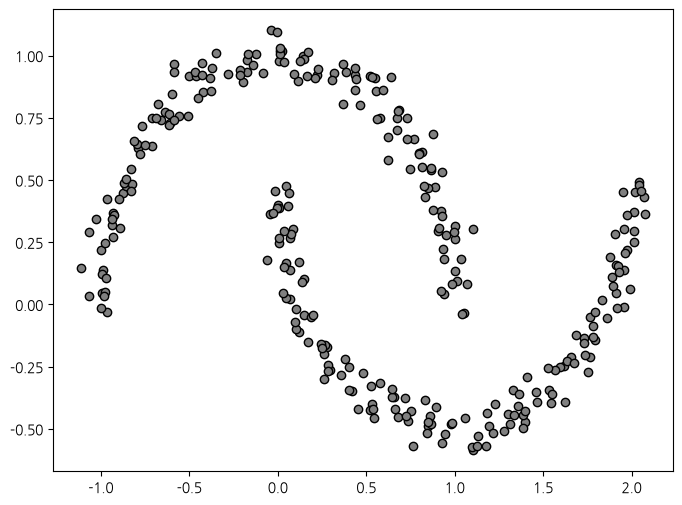

In [3]:
plt.figure(figsize=[8, 6])
plt.scatter(x_train[:, 0], x_train[:, 1], c='gray', edgecolors='black', marker='o')
plt.show()

k평균 클러스터링 모델 생성 후 데이터 학습 및 시각화

In [4]:
model = KMeans(n_clusters=2, init='random', max_iter=100, random_state=0)
model.fit(x_train)
print(model.labels_)

[1 0 0 1 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1
 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 0 0 1
 1 1 0 0 1 0 0 0 1 1 0 0 0 1 1 0 1 0 1 1 1 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0 1
 0 1 0 1 0 0 0 1 0 0 0 0 1 1 1 1 1 1 0 0 0 0 1 1 1 0 1 0 0 1 0 0 0 1 1 1 1
 0 0 0 1 1 1 1 1 1 0 0 1 0 0 1 1 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 1 1
 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 1 0 0 0 1 1 0 0
 1 0 0 0 1 0 0 1 1 1 1 0 1 0 1 0 0 0 1 1 1 0 1 0 0 0 1 0 1 1 0 0 1 0 1 1 0
 0 0 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 1 1 0 1 0 1 1 0
 0 1 0 1]


In [5]:
df = pd.DataFrame(x_train, columns=['x', 'y'])
df['label'] = y_train
df['cluster'] = model.labels_
df

,x,y,label,cluster
0,0.831858,0.430931,0,1
1,0.115706,0.898050,0,0
2,-0.611459,0.729373,0,0
3,1.656398,-0.211761,1,1
4,0.262239,-0.299898,1,0
...,...,...,...,...
295,0.062868,0.447505,1,0
296,-0.859324,0.503234,0,0
297,0.935721,0.221339,0,1
298,-0.828297,0.455657,0,0


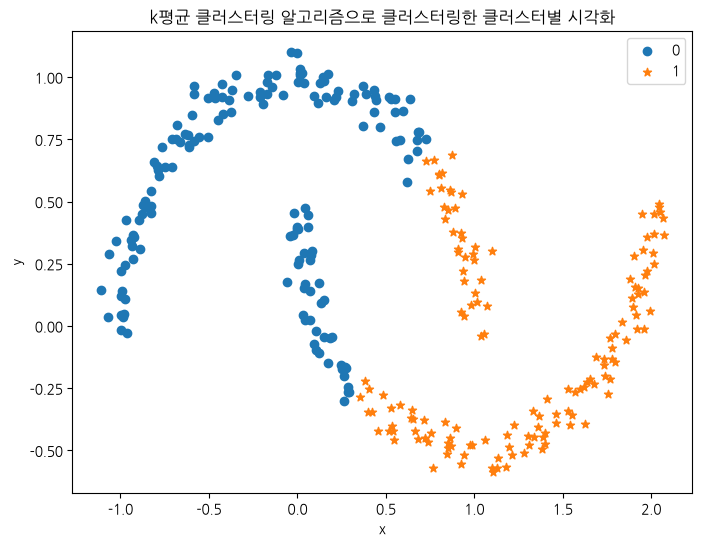

In [6]:
plt.figure(figsize=[8, 6])
markers = ['o', '*']

for index, marker in enumerate(markers):
    df_index = df[df.cluster == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('k평균 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

병합 계층 클러스터링 모델 생성 후 데이터 학습 및 시각화

In [7]:
model = AgglomerativeClustering(n_clusters=2, linkage='complete')
model.fit(x_train)
print(model.labels_)

[0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 0 1 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1
 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1
 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 0 1 0 0
 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 1 0
 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 1 1 1 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0
 0 0 0 1]


In [8]:
df = pd.DataFrame(x_train, columns=['x', 'y'])
df['label'] = y_train
df['cluster'] = model.labels_
df

,x,y,label,cluster
0,0.831858,0.430931,0,0
1,0.115706,0.898050,0,0
2,-0.611459,0.729373,0,0
3,1.656398,-0.211761,1,1
4,0.262239,-0.299898,1,0
...,...,...,...,...
295,0.062868,0.447505,1,0
296,-0.859324,0.503234,0,0
297,0.935721,0.221339,0,0
298,-0.828297,0.455657,0,0


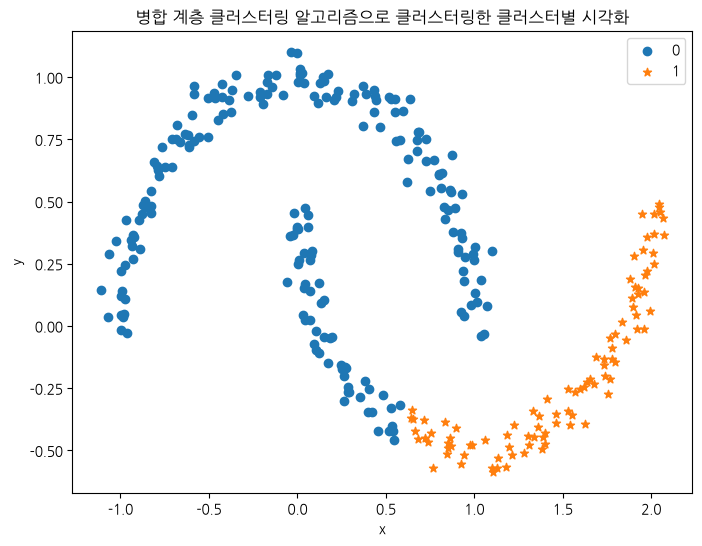

In [9]:
plt.figure(figsize=[8, 6])
markers = ['o', '*']

for index, marker in enumerate(markers):
    df_index = df[df.cluster == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('병합 계층 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

가우시안 혼합 클러스터링 모델 생성 후 데이터 학습 및 시각화

In [10]:
model = GaussianMixture(n_components=2, random_state=0)
model.fit(x_train)
print(model.fit_predict(x_train))

[1 1 1 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 0
 1 0 1 1 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 1 1 1 1 0 0 0 1 1 1 0 0 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 1 1 1 1 0 0 0 0 1 0 0 1 0 0 0
 1 0 1 0 1 1 1 1 1 0 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 0 1 0 0
 1 1 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 0 0 1 1 1 1 1 0 1
 1 1 1 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 1 1 0 1 0 1 1 1 1 0 0 1 1
 0 1 1 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1 0 1 1 0 1 0 0 1 1 0 1 0 0 1
 1 1 1 0 0 0 1 0 0 1 0 1 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 0 1 0 0 1
 1 0 1 0]


In [11]:
df = pd.DataFrame(x_train, columns=['x', 'y'])
df['label'] = y_train
df['cluster'] = model.fit_predict(x_train)
df

,x,y,label,cluster
0,0.831858,0.430931,0,1
1,0.115706,0.898050,0,1
2,-0.611459,0.729373,0,1
3,1.656398,-0.211761,1,0
4,0.262239,-0.299898,1,0
...,...,...,...,...
295,0.062868,0.447505,1,1
296,-0.859324,0.503234,0,1
297,0.935721,0.221339,0,0
298,-0.828297,0.455657,0,1


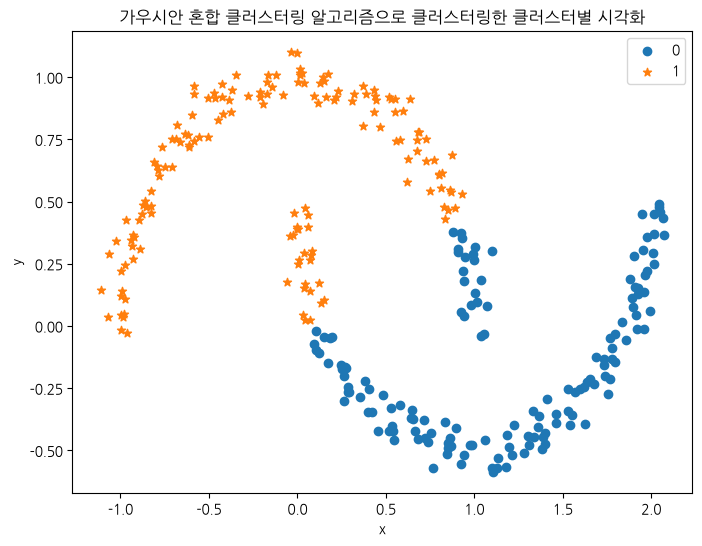

In [12]:
plt.figure(figsize=[8, 6])
markers = ['o', '*']

for index, marker in enumerate(markers):
    df_index = df[df.cluster == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('가우시안 혼합 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

밀도 기반 클러스터링 모델 생성 후 데이터 학습

In [14]:
# min_samples 속성으로 일정 반경내에 최소한의 데이터 포인트 개수, eps 속성으로 데이터 포인트 개수를 측정할 반경을 지정해서 밀도 기반 클러스터 모델을 만든다.
model = DBSCAN(min_samples=5, eps=0.2)
# 밀도 기반 클러스터링은 비지도 학습이므로 학습 데이터만 넘겨서 모델을 학습시킨다.
model.fit(x_train)

DBSCAN(eps=0.2)

In [15]:
# 클러스터링 결과를 확인한다.
# labels_ 속성으로 클러스터링 결과를 확인할 수 있다.
print(model.labels_)
# fit_predict() 메소드에 피쳐 데이터를 넘겨서 예측하면 클러스터링 결과와 같은 결과가 나온다.
print(model.fit_predict(x_train))

[0 0 0 1 1 1 0 0 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 0 1 1 1 1
 0 1 0 0 1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 0 1 1 0 0 1
 1 1 1 1 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 0
 0 1 0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0 0 1 0 0 0
 0 0 0 0 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 0 0 0 0 1 0
 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 1 1 1 1 0
 1 0 0 0 1 0 1 1 1 1 0 0 0 1 1 0 0 0 1 1 1 0 0 1 0 0 1 0 1 0 0 0 1 0 1 1 0
 0 0 0 1 1 1 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 0 1 1
 0 0 0 1]
[0 0 0 1 1 1 0 0 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 0 1 1 1 1
 0 1 0 0 1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 0 1 1 0 0 1
 1 1 1 1 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 0
 0 1 0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0 0 1 0 0 0
 0 0 0 0 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 0 0 0 0 1 0
 1 0 0 1 1 0 1 

밀도 기반 클러스터링 알고리즘으로 클러스터링 된 데이터 시각화

In [16]:
# 클러스터링된 데이터를 시각화 하기 위해서 데이터프레임으로 만든다.
df = pd.DataFrame(x_train, columns=['x', 'y'])
df['label'] = y_train
df['cluster'] = model.labels_
df

,x,y,label,cluster
0,0.831858,0.430931,0,0
1,0.115706,0.898050,0,0
2,-0.611459,0.729373,0,0
3,1.656398,-0.211761,1,1
4,0.262239,-0.299898,1,1
...,...,...,...,...
295,0.062868,0.447505,1,1
296,-0.859324,0.503234,0,0
297,0.935721,0.221339,0,0
298,-0.828297,0.455657,0,0


In [17]:
# make_moons() 메소드가 만들어준 레이블과 가우시안 혼합 클러스터링 알고리즘으로 클러스터링된 레이블의 종류 확인
print(set(df.label), set(df.cluster))

{0, 1} {0, 1}


make_moons() 메소드가 만들어준 레이블별 시각화

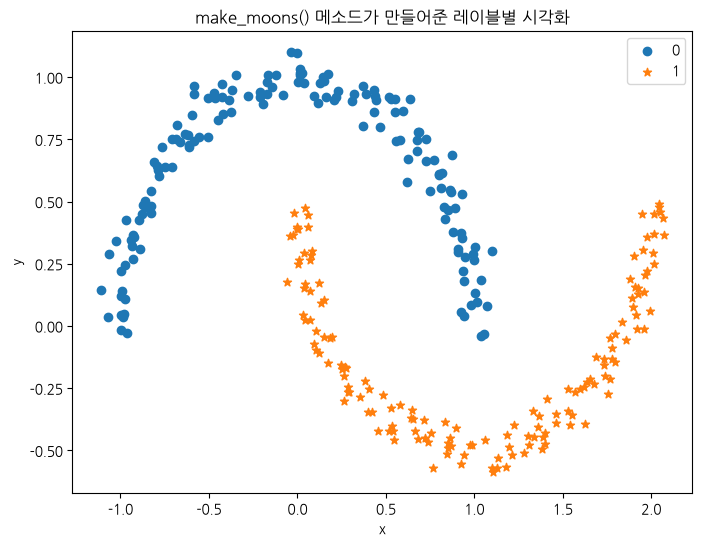

In [18]:
plt.figure(figsize=[8, 6])
markers = ['o', '*']

for index, marker in enumerate(markers):
    df_index = df[df.label == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('make_moons() 메소드가 만들어준 레이블별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

밀도 기반 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화

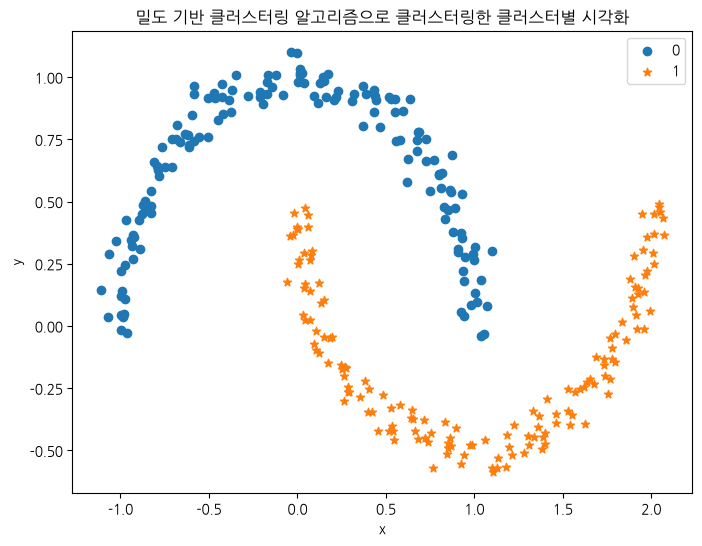

In [19]:
plt.figure(figsize=[8, 6])
markers = ['o', '*']

for index, marker in enumerate(markers):
    df_index = df[df.cluster == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('밀도 기반 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

학습된 모델을 평가한다.

In [20]:
# 실루엣 스코어(silhouette score)는 서로 다른 군집이 얼마나 잘 분리되어 있는지를 나타내는 평가 지표로서 군집 문제에서 모델 성능을 평가한다.
sil_score = silhouette_score(x_train, model.labels_)
print(sil_score)

0.3260472493595187
